Jason Stys

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
except ImportError:
    !pip -q install tensorflow
    import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.initializers import RandomNormal, Zeros, glorot_normal, glorot_uniform

# Reproducibility
tf.keras.utils.set_random_seed(0)
np.random.seed(0)


In [ ]:
n_input = 784
n_dense = 256

b_init = Zeros()
x = np.random.random((1, n_input)).astype(np.float32)


In [ ]:
def run_and_plot(w_init, activation_name, title, bins=30):
    # Reset seed each run so runs are comparable
    tf.keras.utils.set_random_seed(0)

    model = Sequential()
    model.add(Dense(
        n_dense,
        input_dim=n_input,
        kernel_initializer=w_init,
        bias_initializer=b_init
    ))
    model.add(Activation(activation_name))

    a = model.predict(x, verbose=0).flatten()

    print(f"{title}")
    print(f"  mean={a.mean():.4f}, std={a.std():.4f}, min={a.min():.4f}, max={a.max():.4f}")

    plt.figure(figsize=(6, 4))
    plt.hist(a, bins=bins)
    plt.title(title)
    plt.xlabel("Activation value")
    plt.ylabel("Count")
    plt.show()

    return a


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Glorot normal - sigmoid
  mean=0.5053, std=0.1665, min=0.1407, max=0.9083


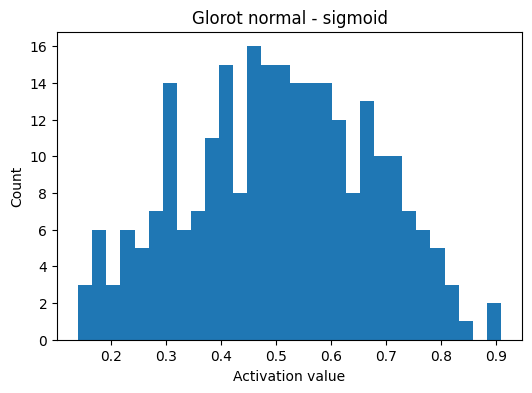

Glorot normal - tanh
  mean=0.0015, std=0.5390, min=-0.9561, max=0.9607


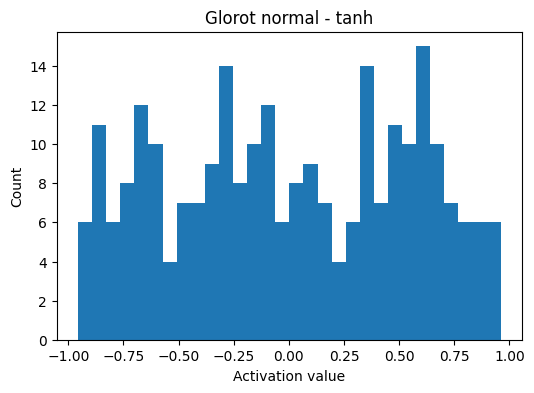

Glorot normal - relu
  mean=0.3021, std=0.4267, min=0.0000, max=1.7740


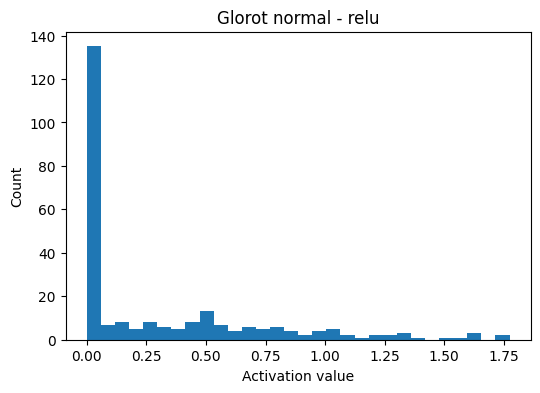

Glorot uniform - sigmoid
  mean=0.5079, std=0.1660, min=0.1392, max=0.8769


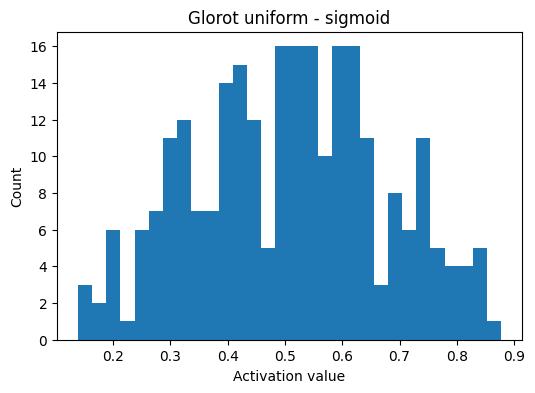

Glorot uniform - tanh
  mean=0.0237, std=0.5083, min=-0.9474, max=0.9557


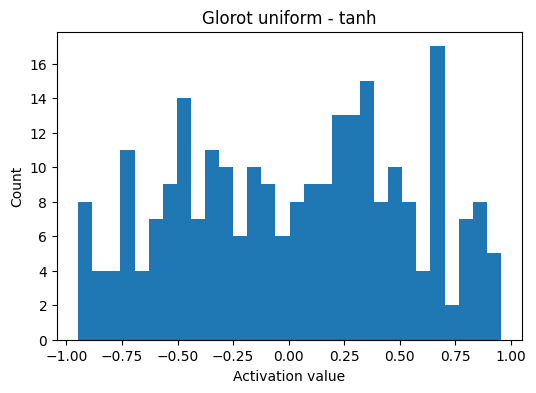

Glorot uniform - relu
  mean=0.3049, std=0.4230, min=0.0000, max=1.7662


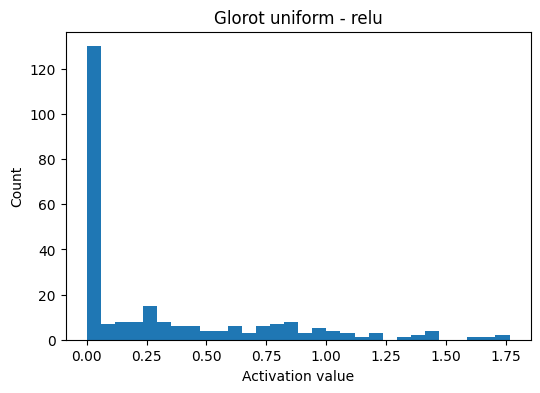

In [ ]:
experiments = [
    ("Glorot normal - sigmoid", glorot_normal(), "sigmoid"),
    ("Glorot normal - tanh",    glorot_normal(), "tanh"),
    ("Glorot normal - relu",    glorot_normal(), "relu"),
    ("Glorot uniform - sigmoid", glorot_uniform(), "sigmoid"),
    ("Glorot uniform - tanh",    glorot_uniform(), "tanh"),
    ("Glorot uniform - relu",    glorot_uniform(), "relu"),
]

results = {}
for title, init, act in experiments:
    results[title] = run_and_plot(init, act, title)
